# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 29: FINAL STRUCTURED MULTI-LABEL UPGRADE
# ============================================================
# Purpose:
# This notebook performs one final structured improvement round
# for the candidate-150 multi-label genre task.
#
# The goal is to:
# 1. Train 3 lightweight structured multi-label models
# 2. Compare them on validation performance
# 3. Tune per-label thresholds for the best model
# 4. Add a label-cap decoding rule to reduce over-prediction
# 5. Save the final improved structured baseline
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import SGDClassifier, PassiveAggressiveClassifier
from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score
)

In [2]:
# ============================================================
# 2. LOAD MULTI-LABEL MASTER TABLE AND FEATURES
# ============================================================

master_df = pd.read_csv("../data/processed/multilabel_candidate_master_table.csv")

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

features.index = features.index.astype(int)

print("Candidate multi-label master shape:", master_df.shape)
print("Features shape:", features.shape)

display(master_df.head())

Candidate multi-label master shape: (81574, 157)
Features shape: (106574, 518)


,track_id,split,subset,genre_top,title,audio_path,audio_exists,genre_1,genre_2,genre_3,...,genre_693,genre_695,genre_741,genre_763,genre_810,genre_811,genre_906,genre_1156,genre_1193,genre_1235
0,20,training,large,NaN,Spiritual Level,../data/raw/audio/fma_large\000\000020.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,26,training,large,NaN,Where is your Love?,../data/raw/audio/fma_large\000\000026.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,30,training,large,NaN,Too Happy,../data/raw/audio/fma_large\000\000030.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,46,training,large,NaN,Yosemite,../data/raw/audio/fma_large\000\000046.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,48,training,large,NaN,Light of Light,../data/raw/audio/fma_large\000\000048.mp3,True,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# ============================================================
# 3. IDENTIFY LABEL COLUMNS
# ============================================================

label_cols = [
    col for col in master_df.columns
    if col.startswith("genre_") and col.replace("genre_", "").isdigit()
]

print("Number of candidate label columns:", len(label_cols))
print("First 10 label columns:", label_cols[:10])

print("\nNon-label genre-like columns:")
print([col for col in master_df.columns if col.startswith("genre_") and col not in label_cols])

Number of candidate label columns: 150
First 10 label columns: ['genre_1', 'genre_2', 'genre_3', 'genre_4', 'genre_5', 'genre_6', 'genre_7', 'genre_8', 'genre_9', 'genre_10']

Non-label genre-like columns:
['genre_top']


In [4]:
# ============================================================
# 4. REMOVE TRACKS WITH NO CANDIDATE LABELS
# ============================================================

master_df["candidate_label_count"] = master_df[label_cols].sum(axis=1)

usable_df = master_df[master_df["candidate_label_count"] > 0].copy().reset_index(drop=True)

print("Original candidate master shape:", master_df.shape)
print("Usable candidate multi-label shape:", usable_df.shape)

print("\nSplit distribution after filtering:")
print(usable_df["split"].value_counts())

print("\nCandidate label count summary:")
print(usable_df["candidate_label_count"].describe())

Original candidate master shape: (81574, 158)
Usable candidate multi-label shape: (79343, 158)

Split distribution after filtering:
split
training      62452
test           8548
validation     8343
Name: count, dtype: int64

Candidate label count summary:
count    79343.000000
mean         3.679329
std          1.735141
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         31.000000
Name: candidate_label_count, dtype: float64


In [5]:
# ============================================================
# 5. ALIGN FEATURES TO USABLE TRACKS
# ============================================================

usable_df["track_id"] = usable_df["track_id"].astype(int)
track_ids = usable_df["track_id"].tolist()

features_aligned = features.reindex(track_ids).copy()

missing_feature_rows = features_aligned.isna().all(axis=1)
num_missing = int(missing_feature_rows.sum())

print("Tracks requested:", len(track_ids))
print("Rows missing from features:", num_missing)

if num_missing > 0:
    usable_df = usable_df.loc[~missing_feature_rows].reset_index(drop=True)
    features_aligned = features_aligned.loc[~missing_feature_rows].copy()

features_aligned = features_aligned.reset_index(drop=True)

print("Aligned features shape:", features_aligned.shape)
print("Usable dataframe shape:", usable_df.shape)

Tracks requested: 79343
Rows missing from features: 0
Aligned features shape: (79343, 518)
Usable dataframe shape: (79343, 158)


In [6]:
# ============================================================
# 6. FLATTEN FEATURE COLUMNS
# ============================================================

features_aligned.columns = [
    "_".join([str(level) for level in col]).strip()
    for col in features_aligned.columns.to_flat_index()
]

print("Flattened features shape:", features_aligned.shape)
display(features_aligned.head())

Flattened features shape: (79343, 518)


,chroma_cens_kurtosis_01,chroma_cens_kurtosis_02,chroma_cens_kurtosis_03,chroma_cens_kurtosis_04,chroma_cens_kurtosis_05,chroma_cens_kurtosis_06,chroma_cens_kurtosis_07,chroma_cens_kurtosis_08,chroma_cens_kurtosis_09,chroma_cens_kurtosis_10,...,tonnetz_std_04,tonnetz_std_05,tonnetz_std_06,zcr_kurtosis_01,zcr_max_01,zcr_mean_01,zcr_median_01,zcr_min_01,zcr_skew_01,zcr_std_01
0,-0.193837,-0.198527,0.201546,0.258556,0.775204,0.084794,-0.289294,-0.816410,0.043851,-0.804761,...,0.095003,0.022492,0.021355,16.669037,0.469727,0.047225,0.040039,0.000977,3.189831,0.030993
1,-0.699535,-0.684158,0.048825,0.042659,-0.818967,-0.917123,-0.901834,-0.066845,-0.291037,-0.861782,...,0.103717,0.025541,0.023846,41.645809,0.250488,0.018388,0.015625,0.000000,4.690596,0.014598
2,-0.721487,-0.848560,0.890904,0.088620,-0.445513,-1.271170,-1.240190,-1.343765,-0.905600,2.671522,...,0.141693,0.020426,0.025418,8.166595,0.546875,0.054417,0.036133,0.002441,2.244708,0.052674
3,-0.119708,-0.858814,2.362546,0.106584,-1.315912,-1.220354,-1.668162,-0.516033,-0.536395,11.025053,...,0.132632,0.033212,0.021310,14.731083,0.223633,0.036601,0.032227,0.000000,2.848736,0.020713
4,-1.054053,0.932339,0.528064,-1.035338,-1.000682,-1.119304,1.166990,-1.002603,-1.094999,-0.725826,...,0.141955,0.024654,0.025203,24.550789,0.371582,0.033015,0.022461,0.000000,4.406733,0.039016


In [7]:
# ============================================================
# 7. PREPARE X AND Y
# ============================================================

X = features_aligned.copy()
X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())
X = X.astype(np.float32)

Y = usable_df[label_cols].copy().astype(np.uint8)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("\nAverage labels per track:", Y.sum(axis=1).mean())
print("Max labels on a track:", Y.sum(axis=1).max())

X shape: (79343, 518)
Y shape: (79343, 150)

Average labels per track: 3.67932898932483
Max labels on a track: 31


In [8]:
# ============================================================
# 8A. CREATE TRAIN / VALIDATION / TEST SPLITS
# ============================================================

split = usable_df["split"].astype(str)

train_mask = (split == "training").values
val_mask = (split == "validation").values
test_mask = (split == "test").values

X_train = X.loc[train_mask].copy()
Y_train = Y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
Y_val = Y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
Y_test = Y.loc[test_mask].copy()

print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

Train: (62452, 518) (62452, 150)
Validation: (8343, 518) (8343, 150)
Test: (8548, 518) (8548, 150)


In [9]:
# ============================================================
# 8B. SAMPLE THE SPLITS FOR A SAFE LAPTOP RUN
# ============================================================

SEED = 42

MAX_TRAIN_ROWS = 20000
MAX_VAL_ROWS = 5000
MAX_TEST_ROWS = 5000

if len(X_train) > MAX_TRAIN_ROWS:
    train_idx = X_train.sample(n=MAX_TRAIN_ROWS, random_state=SEED).index
    X_train = X_train.loc[train_idx].copy()
    Y_train = Y_train.loc[train_idx].copy()

if len(X_val) > MAX_VAL_ROWS:
    val_idx = X_val.sample(n=MAX_VAL_ROWS, random_state=SEED).index
    X_val = X_val.loc[val_idx].copy()
    Y_val = Y_val.loc[val_idx].copy()

if len(X_test) > MAX_TEST_ROWS:
    test_idx = X_test.sample(n=MAX_TEST_ROWS, random_state=SEED).index
    X_test = X_test.loc[test_idx].copy()
    Y_test = Y_test.loc[test_idx].copy()

print("Sampled sizes:")
print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

Sampled sizes:
Train: (20000, 518) (20000, 150)
Validation: (5000, 518) (5000, 150)
Test: (5000, 518) (5000, 150)


In [10]:
# ============================================================
# 9. SCALE FEATURES
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Scaling complete.")

Scaling complete.


In [11]:
# ============================================================
# 10. DEFINE EVALUATION AND DECODING HELPERS
# ============================================================

def evaluate_multilabel(y_true, y_pred, name="Model"):
    return {
        "Model": name,
        "Micro F1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Samples F1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "Micro Precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "Micro Recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "Hamming Loss": hamming_loss(y_true, y_pred),
        "Subset Accuracy": accuracy_score(y_true, y_pred),
        "Avg Predicted Labels": float(y_pred.sum(axis=1).mean())
    }

def get_score_matrix(model, X_input):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_input)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_input)
    else:
        raise ValueError("Model does not support predict_proba or decision_function.")
    return np.asarray(scores)

def decode_scalar_threshold(score_matrix, threshold, ensure_at_least_one=False):
    y_pred = (score_matrix >= threshold).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(score_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def decode_per_label_threshold(score_matrix, thresholds, ensure_at_least_one=False):
    y_pred = np.zeros_like(score_matrix, dtype=np.uint8)

    for j in range(score_matrix.shape[1]):
        y_pred[:, j] = (score_matrix[:, j] >= thresholds[j]).astype(np.uint8)

    if ensure_at_least_one:
        row_sums = y_pred.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(score_matrix[zero_rows], axis=1)
            y_pred[zero_rows, top_idx] = 1

    return y_pred

def apply_label_cap(score_matrix, y_pred, max_labels=None, ensure_at_least_one=False):
    y_final = y_pred.copy()

    if max_labels is not None:
        for i in range(y_final.shape[0]):
            pos_idx = np.where(y_final[i] == 1)[0]

            if len(pos_idx) > max_labels:
                pos_scores = score_matrix[i, pos_idx]
                keep_order = np.argsort(-pos_scores)[:max_labels]
                keep_idx = pos_idx[keep_order]

                y_final[i, :] = 0
                y_final[i, keep_idx] = 1

    if ensure_at_least_one:
        row_sums = y_final.sum(axis=1)
        zero_rows = np.where(row_sums == 0)[0]

        if len(zero_rows) > 0:
            top_idx = np.argmax(score_matrix[zero_rows], axis=1)
            y_final[zero_rows, top_idx] = 1

    return y_final

In [12]:
# ============================================================
# 11. TRAIN THREE STRUCTURED MULTI-LABEL MODELS
# ============================================================

models = {
    "OVR SGD Logistic": OneVsRestClassifier(
        SGDClassifier(
            loss="log_loss",
            alpha=1e-4,
            max_iter=30,
            tol=1e-3,
            class_weight="balanced",
            random_state=42
        ),
        n_jobs=1
    ),
    "OVR SGD Hinge": OneVsRestClassifier(
        SGDClassifier(
            loss="hinge",
            alpha=1e-4,
            max_iter=30,
            tol=1e-3,
            class_weight="balanced",
            random_state=42
        ),
        n_jobs=1
    ),
    "OVR Passive Aggressive": OneVsRestClassifier(
        PassiveAggressiveClassifier(
            C=1.0,
            max_iter=30,
            tol=1e-3,
            class_weight="balanced",
            random_state=42
        ),
        n_jobs=1
    )
}

trained_models = {}
val_score_dict = {}
validation_model_results = []

for model_name, model in models.items():
    print(f"\nTraining {model_name} ...")
    model.fit(X_train_scaled, Y_train)

    trained_models[model_name] = model
    val_scores = get_score_matrix(model, X_val_scaled)
    val_score_dict[model_name] = val_scores

    # Default threshold
    if "Logistic" in model_name:
        default_threshold = 0.5
    else:
        default_threshold = 0.0

    Y_val_pred = decode_scalar_threshold(
        val_scores,
        threshold=default_threshold,
        ensure_at_least_one=False
    )

    results = evaluate_multilabel(Y_val, Y_val_pred, name=model_name)
    results["Default Threshold"] = default_threshold

    validation_model_results.append(results)
    print(results)

validation_models_df = pd.DataFrame(validation_model_results).sort_values(
    "Micro F1", ascending=False
).reset_index(drop=True)

print("\nValidation model comparison:")
display(validation_models_df)


Training OVR SGD Logistic ...


c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

{'Model': 'OVR SGD Logistic', 'Micro F1': 0.16195028974591513, 'Macro F1': 0.08093826711139597, 'Samples F1': 0.16160643833136884, 'Micro Precision': 0.095269958676565, 'Micro Recall': 0.5396711570967577, 'Hamming Loss': 0.14538933333333334, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 22.1182, 'Default Threshold': 0.5}

Training OVR SGD Hinge ...


c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

{'Model': 'OVR SGD Hinge', 'Micro F1': 0.16533077749522712, 'Macro F1': 0.08169435589256198, 'Samples F1': 0.16511085222550514, 'Micro Precision': 0.09735649134305532, 'Micro Recall': 0.5478153972237874, 'Hamming Loss': 0.14398266666666668, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 21.9708, 'Default Threshold': 0.0}

Training OVR Passive Aggressive ...


c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\jdevo\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider i

{'Model': 'OVR Passive Aggressive', 'Micro F1': 0.12076803997718694, 'Macro F1': 0.0688227844316684, 'Samples F1': 0.12008075739428518, 'Micro Precision': 0.06754687632912469, 'Micro Recall': 0.5694309276238283, 'Hamming Loss': 0.215828, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 32.9164, 'Default Threshold': 0.0}

Validation model comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Default Threshold
0,OVR SGD Hinge,0.165331,0.081694,0.165111,0.097356,0.547815,0.143983,0.0,21.9708,0.0
1,OVR SGD Logistic,0.161950,0.080938,0.161606,0.095270,0.539671,0.145389,0.0,22.1182,0.5
2,OVR Passive Aggressive,0.120768,0.068823,0.120081,0.067547,0.569431,0.215828,0.0,32.9164,0.0


In [13]:
# ============================================================
# 12. SELECT BEST BASE MODEL
# ============================================================

best_model_name = validation_models_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

val_scores_best = val_score_dict[best_model_name]
test_scores_best = get_score_matrix(best_model, X_test_scaled)

print("Best base model:", best_model_name)
print("Validation score matrix shape:", val_scores_best.shape)
print("Test score matrix shape:", test_scores_best.shape)

Best base model: OVR SGD Hinge
Validation score matrix shape: (5000, 150)
Test score matrix shape: (5000, 150)


In [14]:
# ============================================================
# 13. LEARN PER-LABEL THRESHOLDS FOR THE BEST MODEL
# ============================================================

if "Logistic" in best_model_name:
    per_label_grid = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
else:
    per_label_grid = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])

best_thresholds_per_label = np.zeros(val_scores_best.shape[1], dtype=np.float32)

for j in range(val_scores_best.shape[1]):
    y_true_j = Y_val.iloc[:, j].values
    scores_j = val_scores_best[:, j]

    best_f1_j = -1.0
    best_t_j = per_label_grid[0]

    for t in per_label_grid:
        y_pred_j = (scores_j >= t).astype(np.uint8)
        f1_j = f1_score(y_true_j, y_pred_j, zero_division=0)

        if f1_j > best_f1_j:
            best_f1_j = f1_j
            best_t_j = t

    best_thresholds_per_label[j] = best_t_j

print("Per-label thresholds learned.")
print("Unique thresholds selected:", np.unique(best_thresholds_per_label))

Per-label thresholds learned.
Unique thresholds selected: [-1.  -0.5  0.   0.5  1. ]


In [15]:
# ============================================================
# 14. VALIDATION SEARCH: LABEL-CAP DECODING
# ============================================================

base_val_pred = decode_per_label_threshold(
    val_scores_best,
    best_thresholds_per_label,
    ensure_at_least_one=True
)

cap_results = []

for cap in [None, 15, 12, 10, 8, 6, 5, 4, 3]:
    Y_val_pred_cap = apply_label_cap(
        val_scores_best,
        base_val_pred,
        max_labels=cap,
        ensure_at_least_one=True
    )

    cap_name = "Per-Label Thresholds" if cap is None else f"Per-Label Thresholds + Cap-{cap}"

    results = evaluate_multilabel(Y_val, Y_val_pred_cap, name=cap_name)
    results["Cap"] = "None" if cap is None else cap

    cap_results.append(results)

cap_results_df = pd.DataFrame(cap_results).sort_values(
    "Micro F1", ascending=False
).reset_index(drop=True)

print("Validation label-cap tuning results:")
display(cap_results_df)

Validation label-cap tuning results:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels,Cap
0,Per-Label Thresholds,0.168899,0.082488,0.168700,0.099519,0.557701,0.142871,0.0,21.8812,None
1,Per-Label Thresholds + Cap-15,0.112167,0.074160,0.110382,0.070851,0.269067,0.110877,0.0,14.8282,15
2,Per-Label Thresholds + Cap-12,0.086872,0.067720,0.084694,0.057603,0.176612,0.096647,0.0,11.9716,12
3,Per-Label Thresholds + Cap-10,0.070943,0.062179,0.068724,0.049331,0.126261,0.086083,0.0,9.9938,10
4,Per-Label Thresholds + Cap-8,0.054774,0.054661,0.052625,0.040756,0.083491,0.075009,0.0,7.9988,8
5,Per-Label Thresholds + Cap-6,0.039296,0.045746,0.037442,0.032435,0.049839,0.063433,0.0,5.9996,6
6,Per-Label Thresholds + Cap-5,0.032972,0.041579,0.031237,0.029360,0.037597,0.057407,0.0,5.0000,5
7,Per-Label Thresholds + Cap-4,0.025555,0.036157,0.024204,0.025250,0.025867,0.051351,0.0,4.0000,4
8,Per-Label Thresholds + Cap-3,0.019060,0.031471,0.017810,0.021933,0.016852,0.045153,0.0,3.0000,3


In [16]:
# ============================================================
# 15. SELECT BEST DECODING RULE
# ============================================================

best_cap_row = cap_results_df.iloc[0].to_dict()
best_cap_value = best_cap_row["Cap"]

print("Best decoding rule on validation:")
print(best_cap_row)

Best decoding rule on validation:
{'Model': 'Per-Label Thresholds', 'Micro F1': 0.16889916155403362, 'Macro F1': 0.08248818923043892, 'Samples F1': 0.16869968682142966, 'Micro Precision': 0.09951922198051295, 'Micro Recall': 0.5577011729754648, 'Hamming Loss': 0.14287066666666667, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 21.8812, 'Cap': 'None'}


In [17]:
# ============================================================
# 16. APPLY BEST DECODING RULE TO TEST
# ============================================================

base_test_pred = decode_per_label_threshold(
    test_scores_best,
    best_thresholds_per_label,
    ensure_at_least_one=True
)

if best_cap_value == "None":
    final_test_pred = base_test_pred.copy()
else:
    final_test_pred = apply_label_cap(
        test_scores_best,
        base_test_pred,
        max_labels=int(best_cap_value),
        ensure_at_least_one=True
    )

final_test_results = evaluate_multilabel(
    Y_test,
    final_test_pred,
    name=f"{best_model_name} + Best Decoding"
)

print("Final structured test results:")
print(final_test_results)

Final structured test results:
{'Model': 'OVR SGD Hinge + Best Decoding', 'Micro F1': 0.16342705578617783, 'Macro F1': 0.08431567849564779, 'Samples F1': 0.16373645996770694, 'Micro Precision': 0.0955557798720784, 'Micro Recall': 0.5640845070422535, 'Hamming Loss': 0.14214266666666667, 'Subset Accuracy': 0.0, 'Avg Predicted Labels': 21.7946}


In [18]:
# ============================================================
# 17. BUILD TEST COMPARISON TABLE
# ============================================================

# Default test result for the best base model
if "Logistic" in best_model_name:
    default_threshold = 0.5
else:
    default_threshold = 0.0

Y_test_pred_default = decode_scalar_threshold(
    test_scores_best,
    threshold=default_threshold,
    ensure_at_least_one=False
)

default_test_results = evaluate_multilabel(
    Y_test,
    Y_test_pred_default,
    name=f"{best_model_name} - Default"
)

per_label_only_test_pred = decode_per_label_threshold(
    test_scores_best,
    best_thresholds_per_label,
    ensure_at_least_one=True
)

per_label_only_test_results = evaluate_multilabel(
    Y_test,
    per_label_only_test_pred,
    name=f"{best_model_name} - Per-Label Only"
)

test_comparison_df = pd.DataFrame([
    default_test_results,
    per_label_only_test_results,
    final_test_results
])

print("Structured test comparison:")
display(test_comparison_df)

Structured test comparison:


,Model,Micro F1,Macro F1,Samples F1,Micro Precision,Micro Recall,Hamming Loss,Subset Accuracy,Avg Predicted Labels
0,OVR SGD Hinge - Default,0.160855,0.083810,0.161082,0.093984,0.557584,0.143191,0.0,21.9038
1,OVR SGD Hinge - Per-Label Only,0.163427,0.084316,0.163736,0.095556,0.564085,0.142143,0.0,21.7946
2,OVR SGD Hinge + Best Decoding,0.163427,0.084316,0.163736,0.095556,0.564085,0.142143,0.0,21.7946


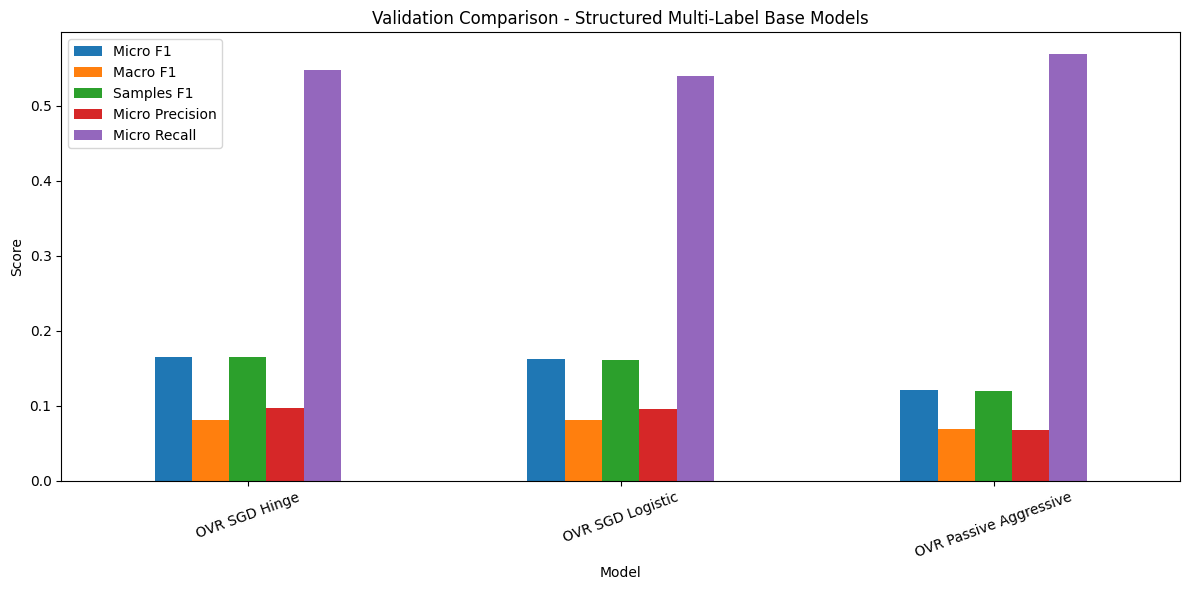

In [19]:
# ============================================================
# 18. PLOT VALIDATION MODEL COMPARISON
# ============================================================

plot_cols = ["Micro F1", "Macro F1", "Samples F1", "Micro Precision", "Micro Recall"]

plot_df = validation_models_df.set_index("Model")[plot_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Validation Comparison - Structured Multi-Label Base Models")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

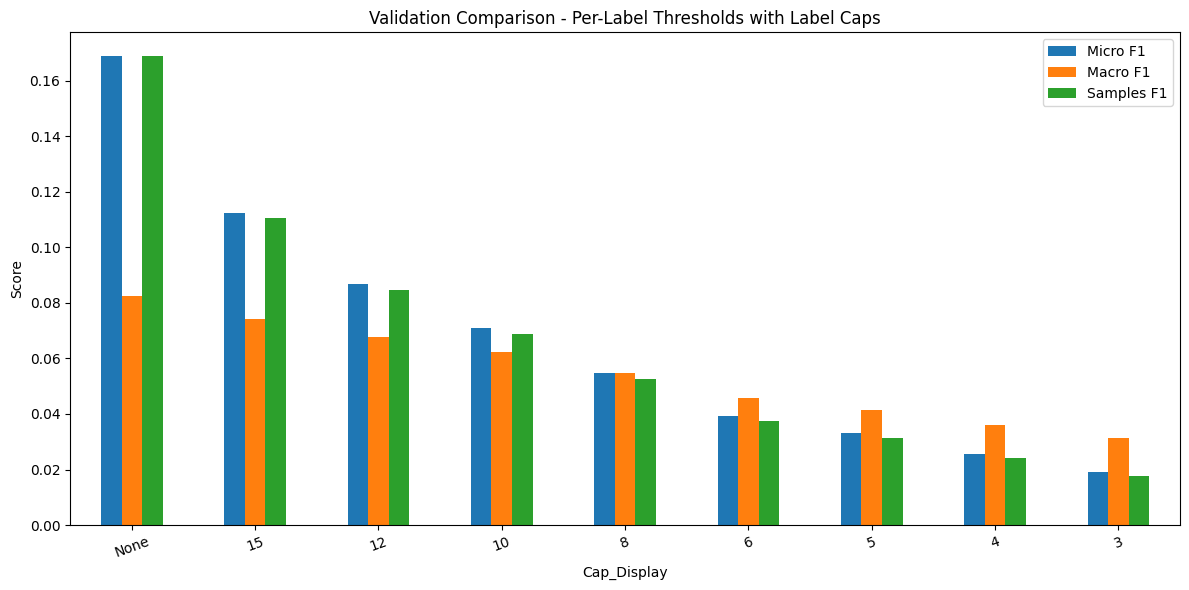

In [20]:
# ============================================================
# 19. PLOT LABEL-CAP VALIDATION SEARCH
# ============================================================

plot_cap_df = cap_results_df.copy()
plot_cap_df["Cap_Display"] = plot_cap_df["Cap"].astype(str)

ax = plot_cap_df.set_index("Cap_Display")[["Micro F1", "Macro F1", "Samples F1"]].plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_title("Validation Comparison - Per-Label Thresholds with Label Caps")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# 20. SAVE OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(best_model, "../models/final_structured_multilabel_candidate150_best_model.joblib")
joblib.dump(scaler, "../models/final_structured_multilabel_candidate150_scaler.joblib")

validation_models_df.to_csv(
    "../data/processed/final_structured_multilabel_candidate150_model_comparison.csv",
    index=False
)

cap_results_df.to_csv(
    "../data/processed/final_structured_multilabel_candidate150_cap_tuning_results.csv",
    index=False
)

test_comparison_df.to_csv(
    "../data/processed/final_structured_multilabel_candidate150_test_comparison.csv",
    index=False
)

pd.DataFrame([final_test_results]).to_csv(
    "../data/processed/final_structured_multilabel_candidate150_test_results.csv",
    index=False
)

np.save(
    "../data/processed/final_structured_multilabel_candidate150_y_test_pred.npy",
    final_test_pred
)

np.save(
    "../data/processed/final_structured_multilabel_candidate150_best_thresholds_per_label.npy",
    best_thresholds_per_label
)

with open("../data/processed/final_structured_multilabel_candidate150_best_model_name.txt", "w") as f:
    f.write(best_model_name)

with open("../data/processed/final_structured_multilabel_candidate150_best_cap.txt", "w") as f:
    f.write(str(best_cap_value))

print("Saved final structured multi-label improvement outputs.")

Saved final structured multi-label improvement outputs.


In [22]:
# ============================================================
# 21. INTERPRETATION NOTES
# ============================================================

print("1. This notebook performs one final structured upgrade pass for the candidate-150 multi-label task.")
print("2. Three structured base models were compared: OVR SGD Logistic, OVR SGD Hinge, and OVR Passive Aggressive.")
print("3. Per-label thresholds were learned for the best model using validation data.")
print("4. A label-cap decoding rule was tuned to reduce over-prediction.")
print("5. The saved result becomes the final improved structured baseline before the audio multi-label phase.")

1. This notebook performs one final structured upgrade pass for the candidate-150 multi-label task.
2. Three structured base models were compared: OVR SGD Logistic, OVR SGD Hinge, and OVR Passive Aggressive.
3. Per-label thresholds were learned for the best model using validation data.
4. A label-cap decoding rule was tuned to reduce over-prediction.
5. The saved result becomes the final improved structured baseline before the audio multi-label phase.
